# CNN Image Classification Project - Final Colab Version

Clean final notebook for Google Colab using:

`C:\Users\Trijan Ratna Shakya\Documents\College\AI ML\Rice Disease Dataset.zip`

Built to avoid earlier problems: slow epochs, overfitting, rising validation loss, and slow transfer learning.

## Cell 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 2: Imports and Configuration

In [2]:
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

SEED = 42
tf.keras.utils.set_random_seed(SEED)

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

EPOCHS_BASELINE = 30
EPOCHS_DEEP = 30
EPOCHS_OPTIMIZER = 15           # was 12 — give optimizers room to converge
EPOCHS_TRANSFER_FEATURE_EXTRACTION = 10
EPOCHS_TRANSFER_FINE_TUNING = 15  # was 3 — 3 epochs is far too few; early stopping decides when to stop

AUTOTUNE = tf.data.AUTOTUNE

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3: Extract Dataset

In [4]:
zip_path = Path('/content/drive/MyDrive/AI 6th Sem/Course Work/archive.zip')
extract_dir = Path('/content/rice_leaf_dataset')
extract_dir.mkdir(parents=True, exist_ok=True)

if not zip_path.exists():
    raise FileNotFoundError(f'Zip file not found: {zip_path}')

if not any(extract_dir.iterdir()):
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print('Dataset already extracted.')

dataset_dir = extract_dir / 'Rice_Leaf_AUG'

if not dataset_dir.exists():
    possible_dirs = []
    for folder in extract_dir.rglob('*'):
        if folder.is_dir():
            child_dirs = [child for child in folder.iterdir() if child.is_dir()]
            if len(child_dirs) >= 2:
                possible_dirs.append(folder)
    if not possible_dirs:
        raise RuntimeError('Could not find class folders after extraction.')
    dataset_dir = possible_dirs[0]

print('Dataset directory:', dataset_dir)
print('Classes:')
for folder in sorted([p for p in dataset_dir.iterdir() if p.is_dir()]):
    print('-', folder.name)

Extracting dataset...
Dataset directory: /content/rice_leaf_dataset/Rice_Leaf_AUG
Classes:
- Bacterial Leaf Blight
- Brown Spot
- Healthy Rice Leaf
- Leaf Blast
- Leaf scald
- Sheath Blight


## Cell 4: Load and Preprocess Data

In [5]:
raw_train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir, validation_split=VALIDATION_SPLIT, subset='training',
    seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

raw_validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir, validation_split=VALIDATION_SPLIT, subset='validation',
    seed=SEED, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

class_names = raw_train_dataset.class_names
num_classes = len(class_names)
print('Class names:', class_names)
print('Number of classes:', num_classes)

normalization_layer = layers.Rescaling(1.0 / 255)

def normalize_images(images, labels):
    return normalization_layer(images), labels

train_dataset = (
    raw_train_dataset
    .map(normalize_images, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000, seed=SEED)
    .prefetch(AUTOTUNE)
)

validation_dataset = (
    raw_validation_dataset
    .map(normalize_images, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

Found 3829 files belonging to 6 classes.
Using 3064 files for training.
Found 3829 files belonging to 6 classes.
Using 765 files for validation.
Class names: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']
Number of classes: 6


## Cell 5: Visualize Sample Images

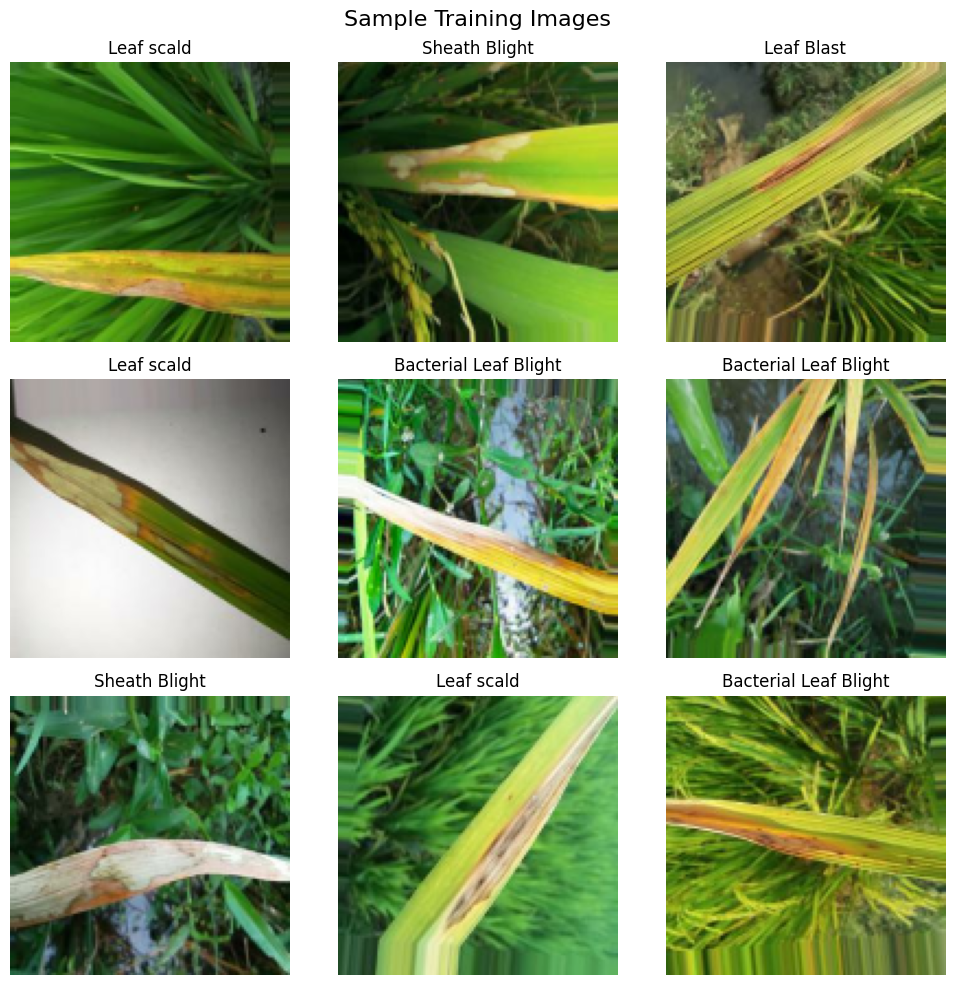

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=16)
plt.tight_layout()
plt.show()

## Cell 6: Class Distribution

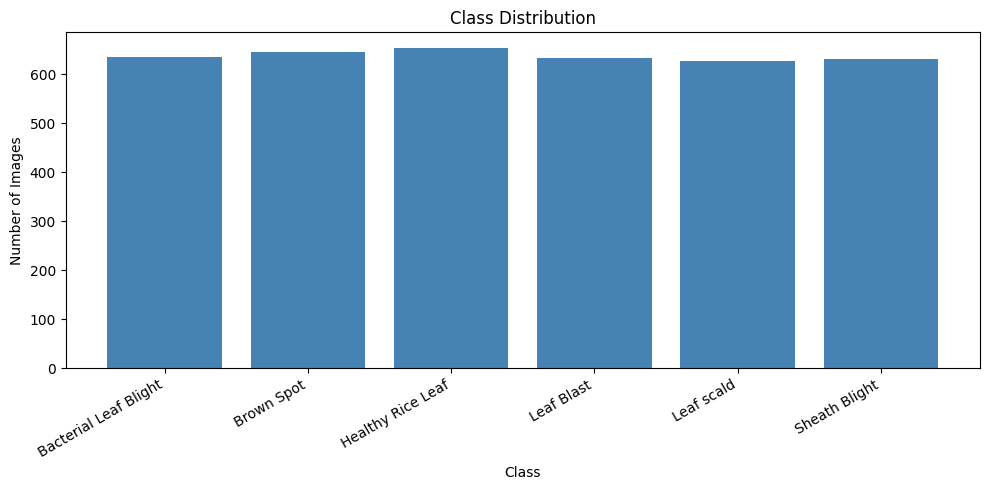

{'Bacterial Leaf Blight': 636, 'Brown Spot': 646, 'Healthy Rice Leaf': 653, 'Leaf Blast': 634, 'Leaf scald': 628, 'Sheath Blight': 632}


In [7]:
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
class_counts = {}
for class_name in class_names:
    class_folder = dataset_dir / class_name
    class_counts[class_name] = sum(
        1 for file_path in class_folder.rglob('*')
        if file_path.suffix.lower() in image_extensions
    )

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(class_counts)

## Cell 6b: Data Augmentation Visualisation

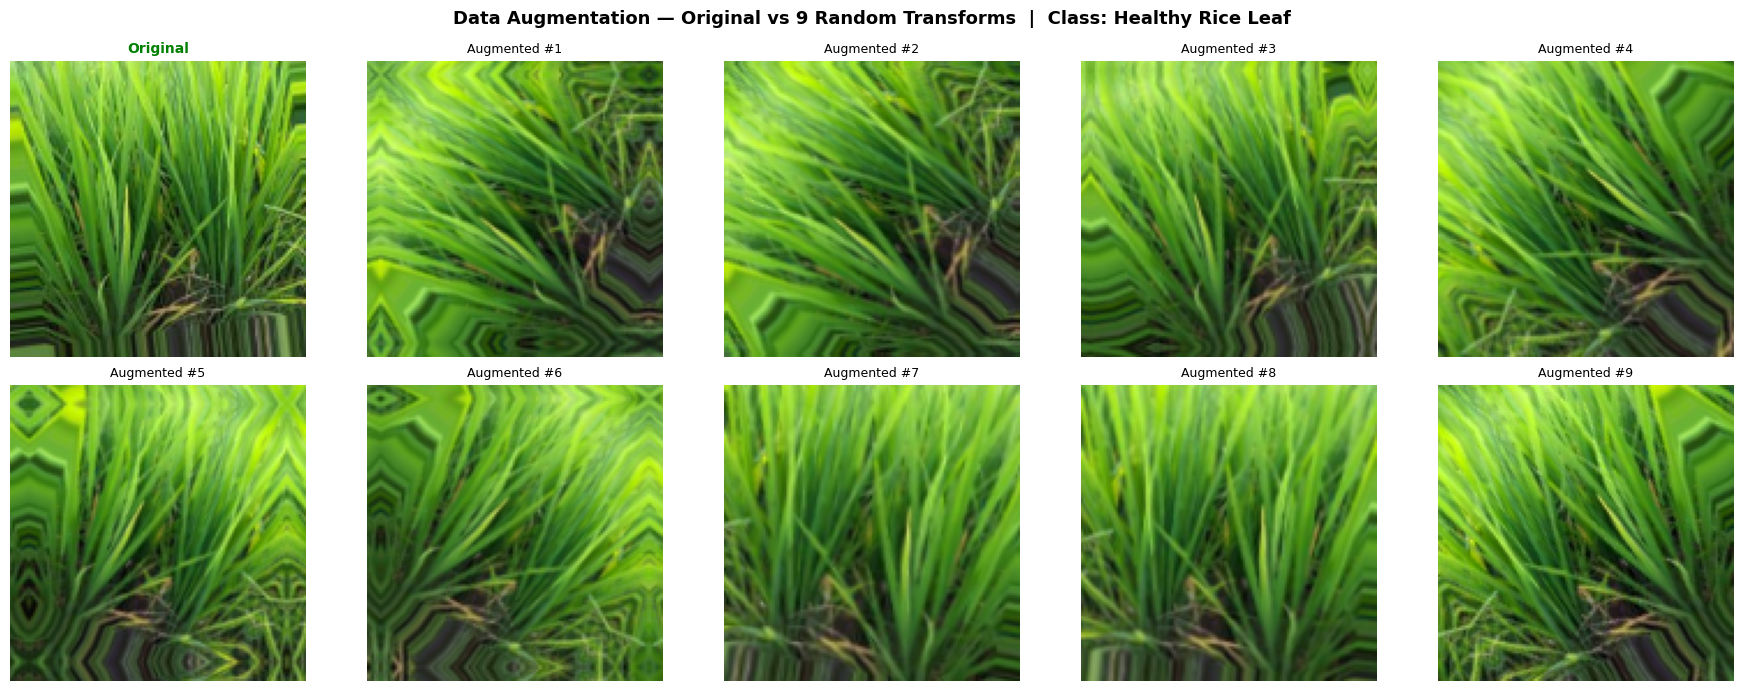

Augmentation pipeline applied during training:
  • RandomFlip("horizontal")
  • RandomRotation(factor=0.15)   → ±15 % of 360°
  • RandomZoom(height_factor=0.15) → ±15 % zoom
  • RandomContrast(factor=0.15)   → ±15 % contrast jitter

Augmentation is ONLY active during model.fit(); it is disabled at evaluation/inference.


In [8]:
# ── Data Augmentation Visualisation ─────────────────────────────────────────
# Required by §2.5.1: show how augmentation transforms the same image
# Define a preview-only augmentation pipeline (same parameters as the one used in training)
aug_preview = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='aug_preview')

# Grab one normalised image from the training set
for _imgs, _labs in train_dataset.take(1):
    orig_img = _imgs[0:1]          # shape (1, 128, 128, 3), float [0, 1]
    orig_label = class_names[int(_labs[0])]
    break

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(
    f'Data Augmentation — Original vs 9 Random Transforms  |  Class: {orig_label}',
    fontsize=13, fontweight='bold'
)

# Column 0, Row 0 = original
axes[0, 0].imshow(orig_img[0].numpy())
axes[0, 0].set_title('Original', fontsize=10, color='green', fontweight='bold')
axes[0, 0].axis('off')

# Remaining 9 slots = augmented versions
for idx, ax in enumerate(list(axes.flat)[1:]):
    aug = aug_preview(orig_img, training=True)[0].numpy()
    aug = np.clip(aug, 0.0, 1.0)
    ax.imshow(aug)
    ax.set_title(f'Augmented #{idx + 1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Augmentation pipeline applied during training:')
print('  • RandomFlip("horizontal")')
print('  • RandomRotation(factor=0.15)   → ±15 % of 360°')
print('  • RandomZoom(height_factor=0.15) → ±15 % zoom')
print('  • RandomContrast(factor=0.15)   → ±15 % contrast jitter')
print('\nAugmentation is ONLY active during model.fit(); it is disabled at evaluation/inference.')

## Cell 7: Helper Functions

In [9]:
def make_callbacks(patience=4):
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience, restore_best_weights=True
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=max(1, patience // 2),
        min_lr=1e-6, verbose=1
    )
    return [early_stopping, reduce_lr]

def plot_training_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title}: Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def collect_predictions(model, dataset):
    y_true_batches, y_pred_batches = [], []
    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)
        y_true_batches.append(labels.numpy())
        y_pred_batches.append(predictions)
    return np.concatenate(y_true_batches), np.concatenate(y_pred_batches)

def evaluate_model(model, dataset, class_names, title):
    loss, accuracy = model.evaluate(dataset, verbose=0)
    y_true, y_pred = collect_predictions(model, dataset)

    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'{title} Results')
    print('-' * 40)
    print(f'Validation Loss:      {loss:.4f}')
    print(f'Validation Accuracy:  {accuracy:.4f}')
    print(f'Weighted Precision:   {precision:.4f}')
    print(f'Weighted Recall:      {recall:.4f}')
    print(f'Weighted F1-score:    {f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    plt.title(f'{title}: Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {'loss': loss, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

def print_results_table(results):
    print(f"{'Model':<35} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-score':>10}")
    print('-' * 80)
    for name, m in results.items():
        print(f"{name:<35} {m['accuracy']:>10.4f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

## Cell 8: Baseline CNN From Scratch

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='data_augmentation')

def build_baseline_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.50),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='improved_baseline_cnn')
    return model

baseline_model = build_baseline_cnn(IMAGE_SIZE + (3,), num_classes)
baseline_model.summary()

Model: "improved_baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,294 (469.90 KB)

 Trainable params: 120,294 (469.90 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 9: Baseline CNN Training

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.1821 - loss: 1.7834 - val_accuracy: 0.2654 - val_loss: 1.7217 - learning_rate: 0.0010
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2624 - loss: 1.7046 - val_accuracy: 0.2196 - val_loss: 1.7319 - learning_rate: 0.0010
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2914 - loss: 1.6481 - val_accuracy: 0.3503 - val_loss: 1.5499 - learning_rate: 0.0010
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3701 - loss: 1.4690 - val_accuracy: 0.3765 - val_loss: 1.5448 - learning_rate: 0.0010
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4413 - loss: 1.3824 - val_accuracy: 0.4562 - val_loss: 1.3151 - learning_rate: 0.0010
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4602 - loss: 1.3268 - val_accuracy: 0.5190 - val_loss: 1.2438 - learning_rate: 0.0010
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4925 - loss: 1.2754 - val_ac

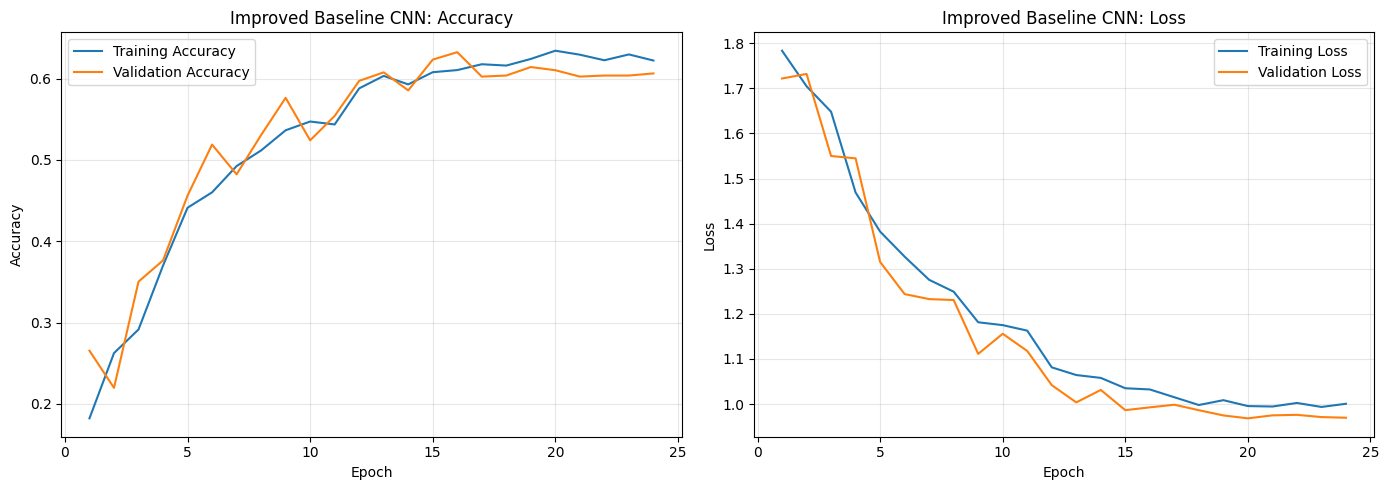

Improved Baseline CNN Results
----------------------------------------
Validation Loss:      0.9683
Validation Accuracy:  0.6105
Weighted Precision:   0.6102
Weighted Recall:      0.6105
Weighted F1-score:    0.6022

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.50      0.63      0.56       109
           Brown Spot       0.59      0.60      0.60       139
    Healthy Rice Leaf       0.85      0.89      0.87       133
           Leaf Blast       0.69      0.43      0.53       111
           Leaf scald       0.44      0.34      0.38       137
        Sheath Blight       0.60      0.74      0.66       136

             accuracy                           0.61       765
            macro avg       0.61      0.61      0.60       765
         weighted avg       0.61      0.61      0.60       765



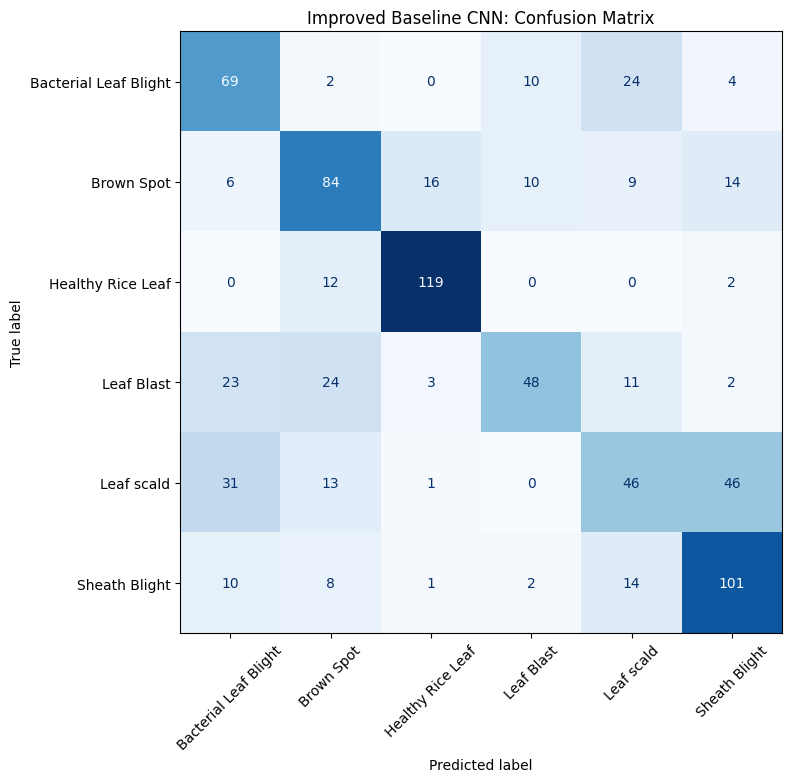

In [11]:
import time

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

_t0 = time.time()
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_BASELINE,
    callbacks=make_callbacks(patience=4)
)
baseline_train_time = time.time() - _t0

print(f"\nBaseline CNN — Training time : {baseline_train_time:.1f}s "
      f"({baseline_train_time / 60:.1f} min) | "
      f"Epochs completed : {len(baseline_history.history['accuracy'])}")

plot_training_history(baseline_history, 'Improved Baseline CNN')
baseline_results = evaluate_model(baseline_model, validation_dataset, class_names, 'Improved Baseline CNN')

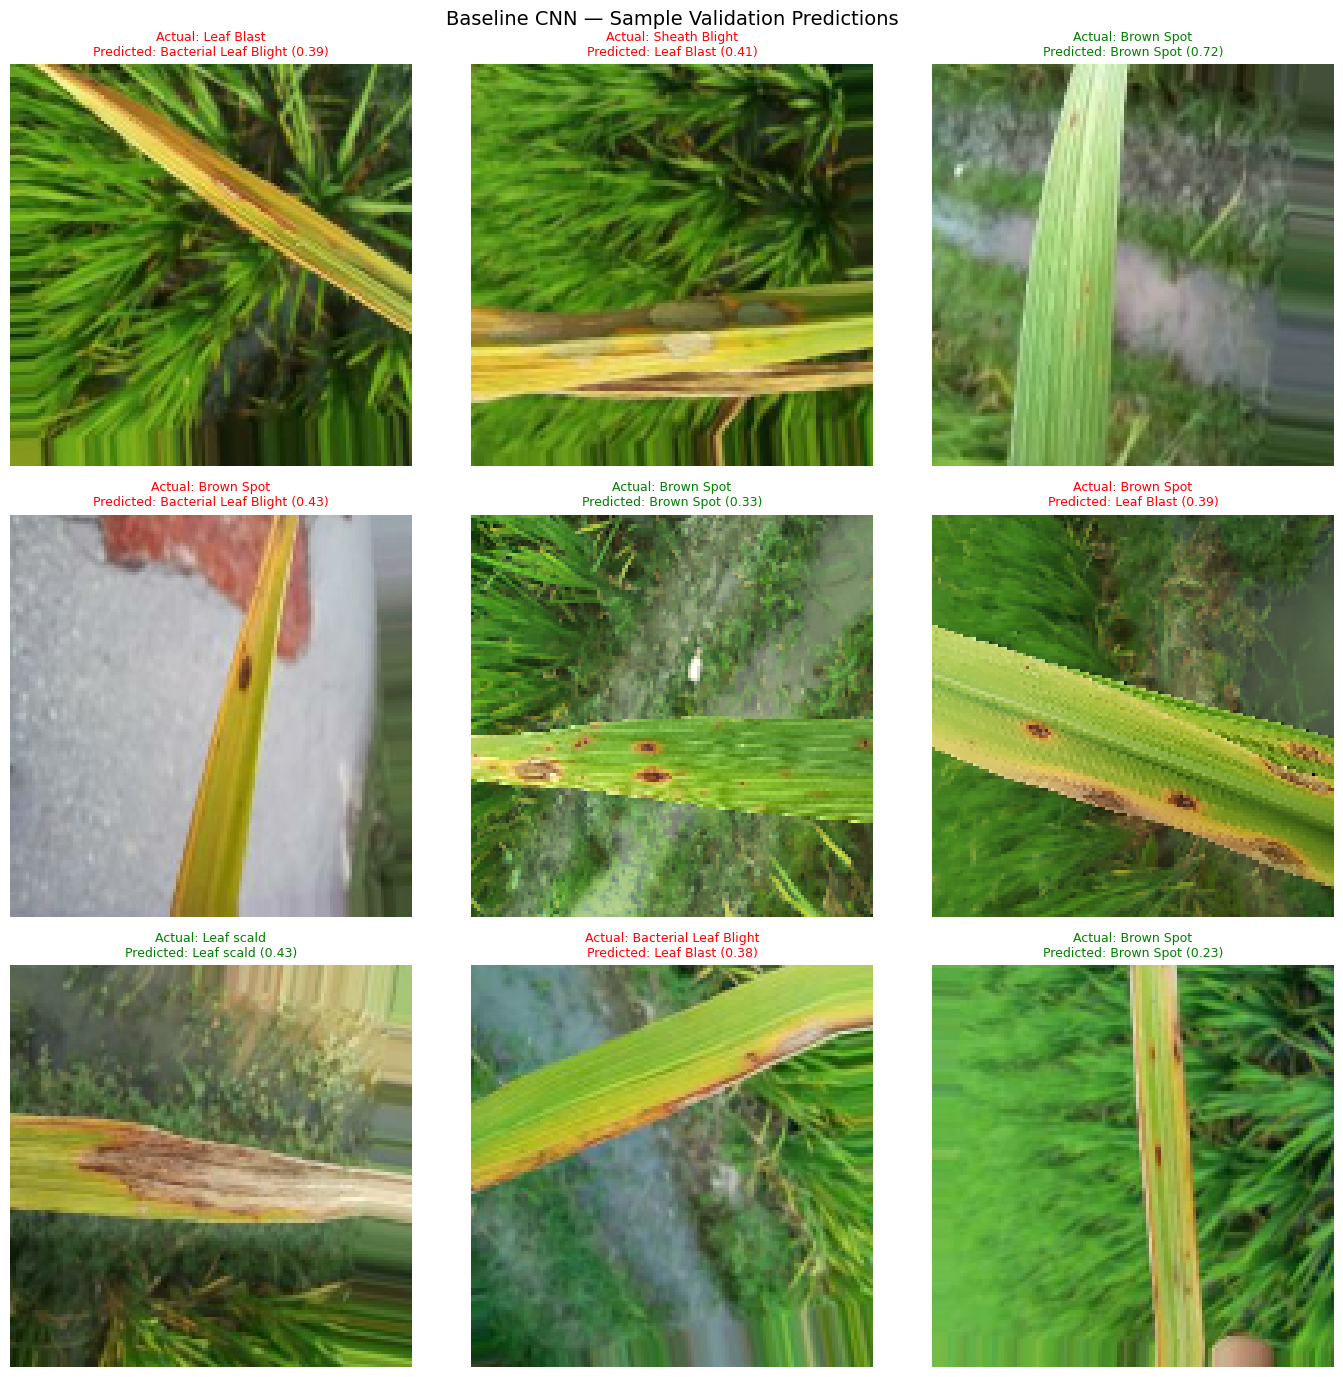

In [12]:
# §2.5.2.3 — Baseline model inference on sample validation images
plt.figure(figsize=(14, 14))
for images, labels in validation_dataset.take(1):
    probabilities = baseline_model.predict(images, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)

    for i in range(min(9, images.shape[0])):
        actual_label    = class_names[int(labels[i])]
        predicted_label = class_names[int(predicted_labels[i])]
        confidence      = np.max(probabilities[i])
        color = 'green' if actual_label == predicted_label else 'red'

        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(
            f'Actual: {actual_label}\nPredicted: {predicted_label} ({confidence:.2f})',
            fontsize=9, color=color
        )
        plt.axis('off')

plt.suptitle('Baseline CNN — Sample Validation Predictions', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 10: Deeper CNN

In [13]:
def build_deeper_cnn(input_shape, num_classes):
    # Fresh augmentation layer created INSIDE the function — never shared with other models.
    # Sharing a Keras Sequential augmentation layer across multiple trained models
    # causes graph conflicts and training collapse (val_acc stuck at ~17 %, all preds → 1 class).
    aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_deeper')

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        aug,

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.35),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation='softmax'),
    ], name='deeper_cnn')
    return model

deep_model = build_deeper_cnn(IMAGE_SIZE + (3,), num_classes)
deep_model.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_deeper (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 314,470 (1.20 MB)

 Trainable params: 313,318 (1.20 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Cell 11: Deeper CNN Training

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.3450 - loss: 1.8072 - val_accuracy: 0.1686 - val_loss: 1.9775 - learning_rate: 3.0000e-04
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4661 - loss: 1.4924 - val_accuracy: 0.1961 - val_loss: 2.8837 - learning_rate: 3.0000e-04
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5127 - loss: 1.3494 - val_accuracy: 0.1778 - val_loss: 3.8309 - learning_rate: 3.0000e-04
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5567 - loss: 1.2301
Epoch 4: ReduceLROnPlateau reducing learning rate to 6.000000284984708e-05.
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.5695 - loss: 1.2115 - val_accuracy: 0.2850 - val_loss: 2.3815 - learning_rate: 3.0000e-04
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.6054 - loss: 1.1197 - val_accuracy: 0.4013 - val_loss: 1.8191 - learning_rate: 6.0000e-05
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.632

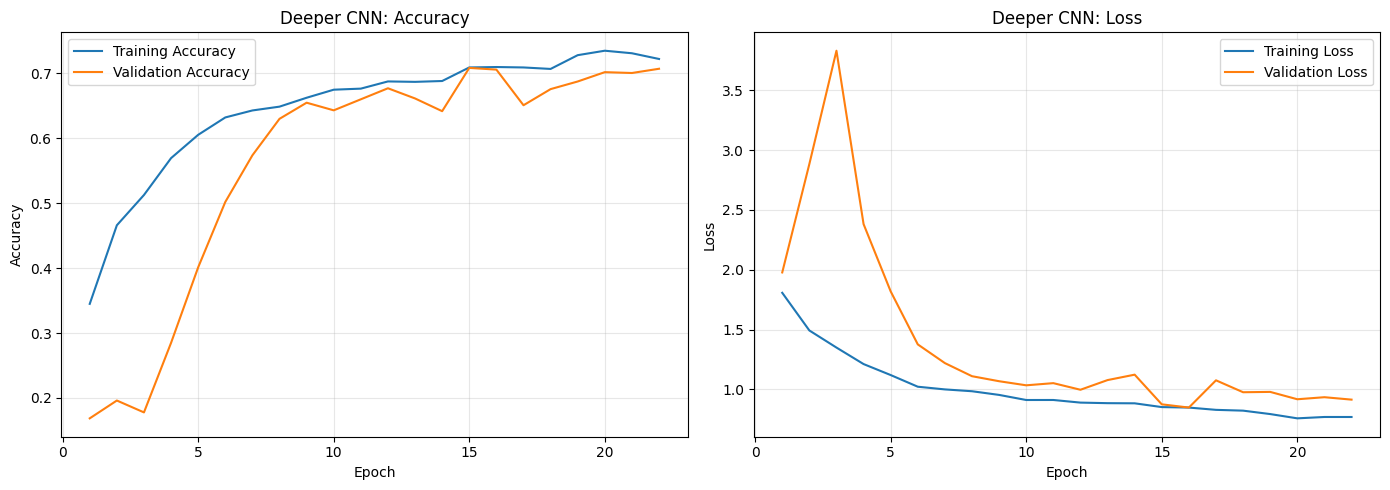

Deeper CNN Results
----------------------------------------
Validation Loss:      0.8479
Validation Accuracy:  0.7059
Weighted Precision:   0.7563
Weighted Recall:      0.7059
Weighted F1-score:    0.7018

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.49      0.88      0.63       109
           Brown Spot       0.64      0.85      0.73       139
    Healthy Rice Leaf       0.82      0.89      0.85       133
           Leaf Blast       0.82      0.53      0.64       111
           Leaf scald       0.83      0.43      0.57       137
        Sheath Blight       0.89      0.66      0.76       136

             accuracy                           0.71       765
            macro avg       0.75      0.71      0.70       765
         weighted avg       0.76      0.71      0.70       765



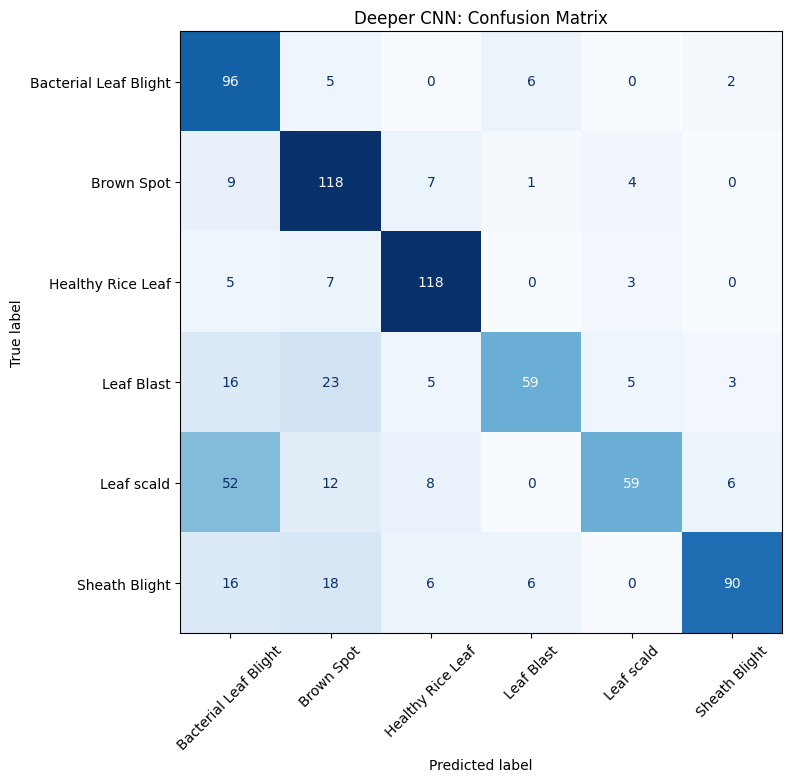

Model                                 Accuracy  Precision     Recall   F1-score
--------------------------------------------------------------------------------
Improved Baseline CNN                   0.6105     0.6102     0.6105     0.6022
Deeper CNN                              0.7059     0.7563     0.7059     0.7018

COMPUTATIONAL EFFICIENCY COMPARISON  (Hardware: Google Colab GPU)
Model                          Parameters   Train Time (s)   Epochs
------------------------------------------------------------------------
Baseline CNN                      120,294             64.3       24
Deeper CNN                        314,470            221.1       22

Deeper CNN has 2.6x more parameters and took 3.4x longer to train.
Trade-off: deeper models learn richer features but cost more compute and memory.
BatchNorm + Dropout add overhead per step but typically require fewer epochs.


In [14]:
import time

# Lower LR (0.001 → 0.0003) — prevents the val loss spike caused by
# large early updates before BatchNorm running stats stabilise.
# clipnorm=1.0 — caps gradient magnitude so no single step destroys
# the freshly-initialised BatchNorm layers.
deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

_t0 = time.time()
deep_history = deep_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_DEEP,
    callbacks=make_callbacks(patience=6)   # patience=6 — give it room to recover from dips
)
deep_train_time = time.time() - _t0

print(f"\nDeeper CNN — Training time : {deep_train_time:.1f}s "
      f"({deep_train_time / 60:.1f} min) | "
      f"Epochs completed : {len(deep_history.history['accuracy'])}")

plot_training_history(deep_history, 'Deeper CNN')
deep_results = evaluate_model(deep_model, validation_dataset, class_names, 'Deeper CNN')

model_results = {
    'Improved Baseline CNN': baseline_results,
    'Deeper CNN':            deep_results,
}
print_results_table(model_results)

# ── §2.5.4 Computational Efficiency Comparison ───────────────────────────────
baseline_params = baseline_model.count_params()
deep_params     = deep_model.count_params()

print("\n" + "=" * 72)
print("COMPUTATIONAL EFFICIENCY COMPARISON  (Hardware: Google Colab GPU)")
print("=" * 72)
print(f"{'Model':<26} {'Parameters':>14} {'Train Time (s)':>16} {'Epochs':>8}")
print("-" * 72)
print(f"{'Baseline CNN':<26} {baseline_params:>14,} {baseline_train_time:>16.1f} "
      f"{len(baseline_history.history['accuracy']):>8}")
print(f"{'Deeper CNN':<26} {deep_params:>14,} {deep_train_time:>16.1f} "
      f"{len(deep_history.history['accuracy']):>8}")
print("=" * 72)
speedup = deep_train_time / baseline_train_time if baseline_train_time > 0 else float('nan')
print(f"\nDeeper CNN has {deep_params / baseline_params:.1f}x more parameters "
      f"and took {speedup:.1f}x longer to train.")
print("Trade-off: deeper models learn richer features but cost more compute and memory.")
print("BatchNorm + Dropout add overhead per step but typically require fewer epochs.")

## Cell 12: Optimizer Comparison - SGD vs Adam

In [15]:
EPOCHS_OPTIMIZER = 15

def train_deeper_with_optimizer(optimizer, optimizer_name):
    model = build_deeper_cnn(IMAGE_SIZE + (3,), num_classes)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("=" * 60)
    print(f"Training with {optimizer_name}")
    print("=" * 60)

    # Added make_callbacks — without them Adam oscillated wildly (val_loss 3.5x at epoch 3)
    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=EPOCHS_OPTIMIZER,
        callbacks=make_callbacks(patience=4),
        verbose=1
    )

    return model, history


sgd_model, sgd_history = train_deeper_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "SGD, lr=0.01, nesterov=True"
)

adam_model, adam_history = train_deeper_with_optimizer(
    keras.optimizers.Adam(learning_rate=0.001),   # standard Adam lr — 0.0005 was too slow to converge in 12 epochs
    "Adam, lr=0.001"
)

Training with SGD, lr=0.01, nesterov=True
Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.3773 - loss: 1.7066 - val_accuracy: 0.2536 - val_loss: 2.1275 - learning_rate: 0.0100
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.5242 - loss: 1.2796 - val_accuracy: 0.1922 - val_loss: 2.7517 - learning_rate: 0.0100
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.5721 - loss: 1.1319 - val_accuracy: 0.3464 - val_loss: 1.9382 - learning_rate: 0.0100
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.5894 - loss: 1.0759 - val_accuracy: 0.5007 - val_loss: 1.3860 - learning_rate: 0.0100
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.6286 - loss: 1.0241 - val_accuracy: 0.6405 - val_loss: 0.9621 - learning_rate: 0.0100
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.6371 - loss: 0.9884 - val_accuracy: 0.7072 - val_loss: 0.8656 - learning_rate: 0.0100
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step

## Cell 13b: Ablation Study — Effect of Dropout

**§2.5.4 Task 4:** Remove one regularisation component and measure how performance changes.

We rebuild the **exact same Deeper CNN** but strip out all `Dropout` layers, keeping `BatchNormalization` unchanged. Comparing the two isolates Dropout's contribution:
- If validation accuracy **drops** (or train-val gap **widens**) → Dropout is preventing overfitting ✔  
- If results are similar → BatchNorm alone is sufficient for this dataset

Ablation model summary (no Dropout):


Model: "deeper_cnn_no_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aug_no_dropout (Sequential)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           39

 Total params: 314,470 (1.20 MB)

 Trainable params: 313,318 (1.20 MB)

 Non-trainable params: 1,152 (4.50 KB)


Training ablation model (no Dropout)...
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 95ms/step - accuracy: 0.5747 - loss: 1.1814 - val_accuracy: 0.1739 - val_loss: 3.1726 - learning_rate: 0.0010
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.6857 - loss: 0.8848 - val_accuracy: 0.2131 - val_loss: 3.4900 - learning_rate: 0.0010
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7297 - loss: 0.7552
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.7363 - loss: 0.7557 - val_accuracy: 0.2065 - val_loss: 4.1318 - learning_rate: 0.0010
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7911 - loss: 0.5879 - val_accuracy: 0.2092 - val_loss: 3.9280 - learning_rate: 2.0000e-04
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.8254 - loss: 0.5193 - val_accuracy: 0.3007 - val_loss: 2.6423 - learning_rate: 2.0000e-04
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90m

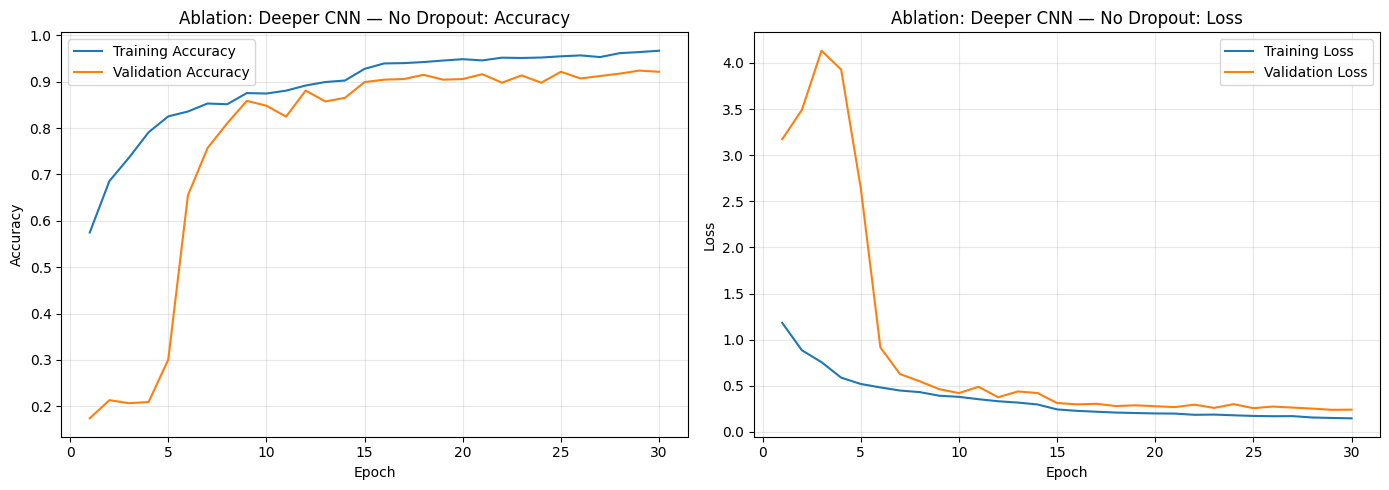

Ablation (No Dropout) Results
----------------------------------------
Validation Loss:      0.2391
Validation Accuracy:  0.9242
Weighted Precision:   0.9244
Weighted Recall:      0.9242
Weighted F1-score:    0.9239

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.92      0.93      0.92       109
           Brown Spot       0.92      0.88      0.90       139
    Healthy Rice Leaf       0.95      1.00      0.97       133
           Leaf Blast       0.86      0.88      0.87       111
           Leaf scald       0.95      0.90      0.92       137
        Sheath Blight       0.93      0.95      0.94       136

             accuracy                           0.92       765
            macro avg       0.92      0.92      0.92       765
         weighted avg       0.92      0.92      0.92       765



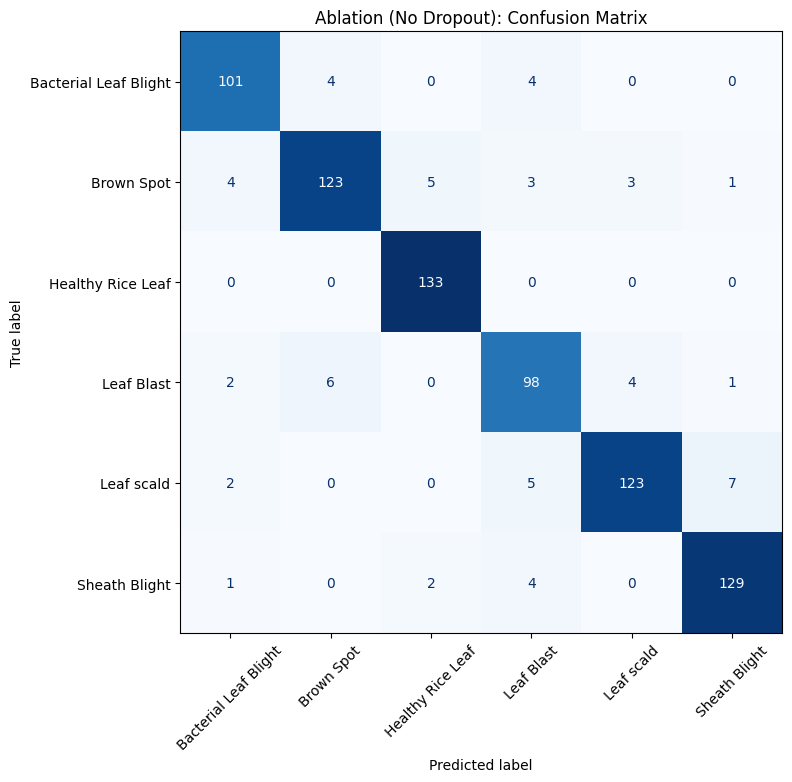


ABLATION STUDY RESULTS — Dropout vs No Dropout
Model                              Val Acc    Val F1  Train-Val Gap   Epochs
------------------------------------------------------------------------
Deeper CNN  (WITH Dropout)          0.7059    0.7018         0.0265       22
Deeper CNN  (NO Dropout)            0.9242    0.9239         0.0429       30

Note: On this dataset BatchNorm alone may be sufficient; Dropout's benefit is marginal. Consider tuning dropout rates.

Conclusion: Dropout randomly zeros activations during training, forcing
the network to learn redundant representations — a key regularisation technique.


In [16]:
# ── Ablation Study: Deeper CNN WITHOUT Dropout ───────────────────────────────
# Identical architecture to deep_model but all Dropout layers removed.

def build_deeper_cnn_no_dropout(input_shape, num_classes):
    # Fresh augmentation layer — same fix as build_deeper_cnn (no shared layers)
    aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
    ], name='aug_no_dropout')

    model = keras.Sequential([
        layers.Input(shape=input_shape),
        aug,

        # Block 1 — no Dropout(0.25)
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 2 — no Dropout(0.30)
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 3 — no Dropout(0.35)
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Head — no Dropout(0.50) or Dropout(0.30)
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ], name='deeper_cnn_no_dropout')
    return model

ablation_model = build_deeper_cnn_no_dropout(IMAGE_SIZE + (3,), num_classes)
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Ablation model summary (no Dropout):")
ablation_model.summary()

print("\nTraining ablation model (no Dropout)...")
ablation_history = ablation_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_DEEP,
    callbacks=make_callbacks(patience=4),
    verbose=1
)

plot_training_history(ablation_history, 'Ablation: Deeper CNN — No Dropout')
ablation_results = evaluate_model(
    ablation_model, validation_dataset, class_names, 'Ablation (No Dropout)'
)

# ── Side-by-side comparison ──────────────────────────────────────────────────
# Train-val accuracy gap reveals degree of overfitting
with_gap    = (max(deep_history.history['accuracy'])
               - max(deep_history.history['val_accuracy']))
without_gap = (max(ablation_history.history['accuracy'])
               - max(ablation_history.history['val_accuracy']))

epochs_with    = len(deep_history.history['accuracy'])
epochs_without = len(ablation_history.history['accuracy'])

print("\n" + "=" * 72)
print("ABLATION STUDY RESULTS — Dropout vs No Dropout")
print("=" * 72)
print(f"{'Model':<32} {'Val Acc':>9} {'Val F1':>9} {'Train-Val Gap':>14} {'Epochs':>8}")
print("-" * 72)
print(f"{'Deeper CNN  (WITH Dropout)':<32} "
      f"{deep_results['accuracy']:>9.4f} {deep_results['f1']:>9.4f} "
      f"{with_gap:>14.4f} {epochs_with:>8}")
print(f"{'Deeper CNN  (NO Dropout)':<32} "
      f"{ablation_results['accuracy']:>9.4f} {ablation_results['f1']:>9.4f} "
      f"{without_gap:>14.4f} {epochs_without:>8}")
print("=" * 72)

if without_gap > with_gap + 0.02:
    print("\n✔ Dropout IS helping: removing it widens the train-val gap "
          f"by {(without_gap - with_gap)*100:.1f}pp — clear sign of overfitting.")
elif ablation_results['accuracy'] < deep_results['accuracy'] - 0.01:
    print("\n✔ Dropout IS helping: validation accuracy is lower without it.")
else:
    print("\nNote: On this dataset BatchNorm alone may be sufficient; "
          "Dropout's benefit is marginal. Consider tuning dropout rates.")

print("\nConclusion: Dropout randomly zeros activations during training, forcing")
print("the network to learn redundant representations — a key regularisation technique.")

## Cell 13: Plot Optimizer Comparison

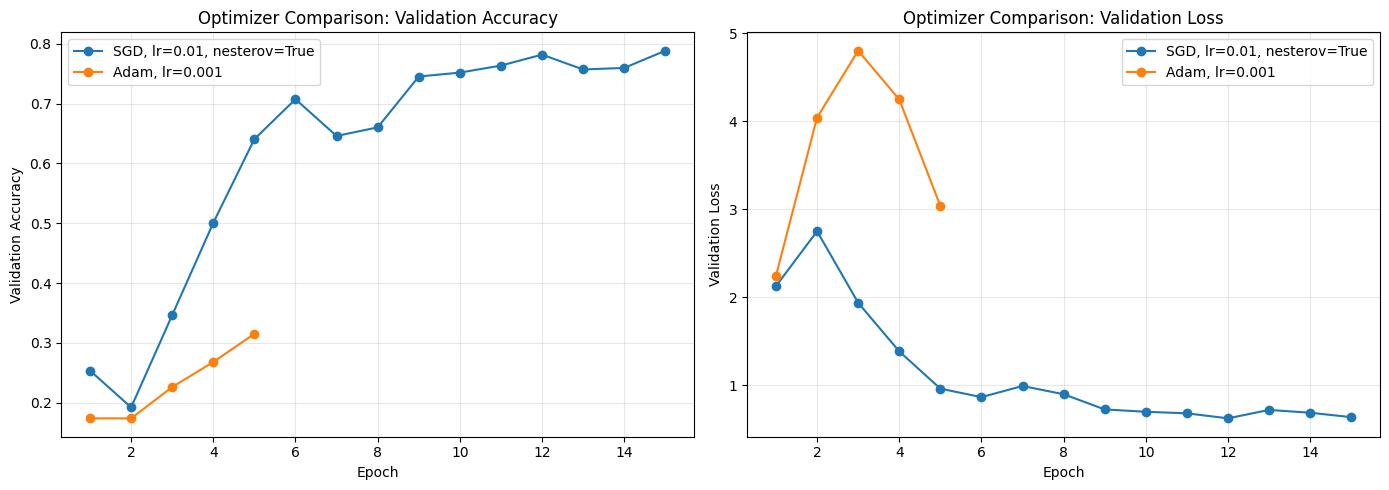

SGD (nesterov) Results
----------------------------------------
Validation Loss:      0.6244
Validation Accuracy:  0.7817
Weighted Precision:   0.7824
Weighted Recall:      0.7817
Weighted F1-score:    0.7806

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.71      0.72      0.72       109
           Brown Spot       0.79      0.81      0.80       139
    Healthy Rice Leaf       0.90      0.98      0.94       133
           Leaf Blast       0.83      0.68      0.75       111
           Leaf scald       0.64      0.67      0.66       137
        Sheath Blight       0.82      0.79      0.81       136

             accuracy                           0.78       765
            macro avg       0.78      0.78      0.78       765
         weighted avg       0.78      0.78      0.78       765



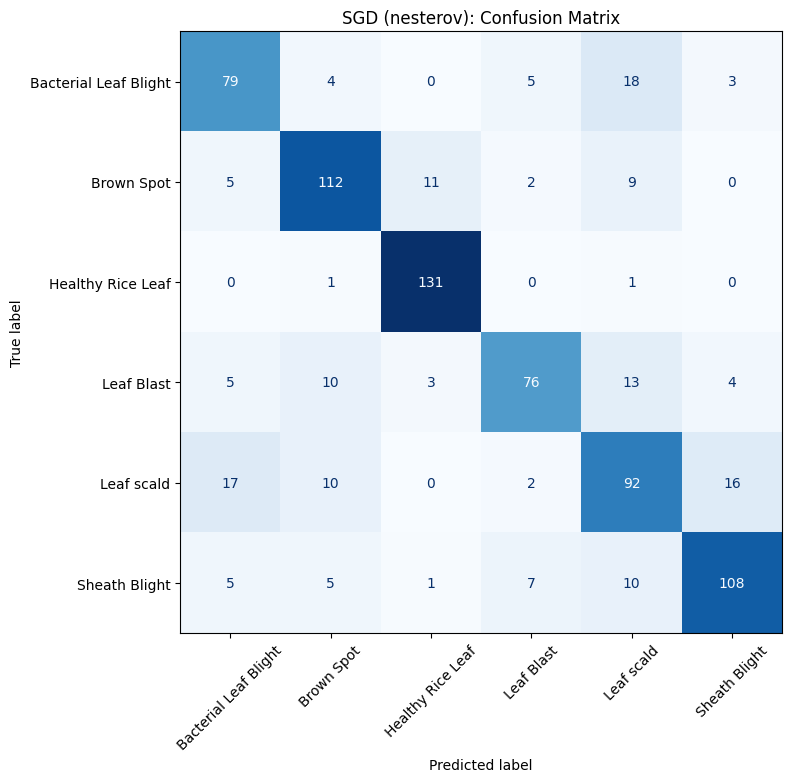

Adam Results
----------------------------------------
Validation Loss:      2.2448
Validation Accuracy:  0.1739
Weighted Precision:   0.0302
Weighted Recall:      0.1739
Weighted F1-score:    0.0515

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.00      0.00      0.00       109
           Brown Spot       0.00      0.00      0.00       139
    Healthy Rice Leaf       0.17      1.00      0.30       133
           Leaf Blast       0.00      0.00      0.00       111
           Leaf scald       0.00      0.00      0.00       137
        Sheath Blight       0.00      0.00      0.00       136

             accuracy                           0.17       765
            macro avg       0.03      0.17      0.05       765
         weighted avg       0.03      0.17      0.05       765



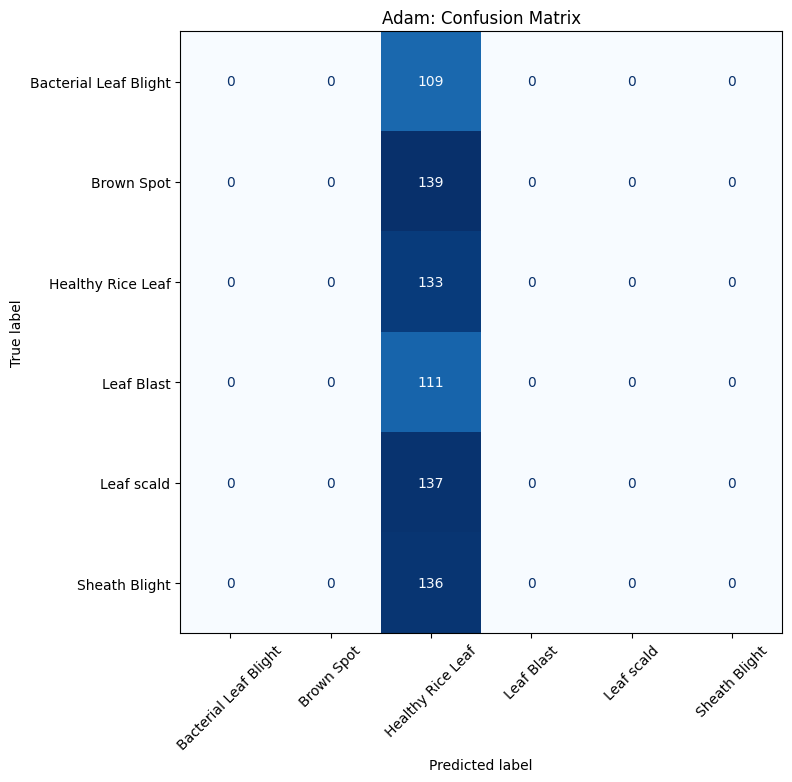


Optimizer Comparison Summary:
Model                                 Accuracy  Precision     Recall   F1-score
--------------------------------------------------------------------------------
SGD, lr=0.01, nesterov=True             0.7817     0.7824     0.7817     0.7806
Adam, lr=0.001                          0.1739     0.0302     0.1739     0.0515


In [17]:
optimizer_histories = {
    "SGD, lr=0.01, nesterov=True": sgd_history,
    "Adam, lr=0.001": adam_history
}

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in optimizer_histories.items():
    epochs = range(1, len(history.history["val_accuracy"]) + 1)
    plt.plot(
        epochs,
        history.history["val_accuracy"],
        marker="o",
        label=name
    )

plt.title("Optimizer Comparison: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in optimizer_histories.items():
    epochs = range(1, len(history.history["val_loss"]) + 1)
    plt.plot(
        epochs,
        history.history["val_loss"],
        marker="o",
        label=name
    )

plt.title("Optimizer Comparison: Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Print optimizer results ──────────────────────────────────────────────────
sgd_results  = evaluate_model(sgd_model,  validation_dataset, class_names, 'SGD (nesterov)')
adam_results = evaluate_model(adam_model, validation_dataset, class_names, 'Adam')

print("\nOptimizer Comparison Summary:")
print_results_table({
    'SGD, lr=0.01, nesterov=True': sgd_results,
    'Adam, lr=0.001':              adam_results,
})

## Cell 14: Transfer Learning With Fast MobileNetV2

In [18]:
data_augmentation_tl = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation_tl')

def build_transfer_learning_model(input_shape, num_classes):
    base_model = keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=0.35
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)

    # Augmentation only active during training; disabled at evaluation/inference
    x = data_augmentation_tl(inputs)

    # Data pipeline delivers float [0,1] images (after Rescaling(1/255)).
    # MobileNetV2 expects [0,255] raw pixels → multiply back before preprocess_input.
    x = layers.Lambda(
        lambda batch: keras.applications.mobilenet_v2.preprocess_input(batch * 255.0),
        name='mobilenetv2_preprocessing'
    )(x)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='fast_mobilenetv2_transfer')
    return model, base_model

transfer_model, transfer_base_model = build_transfer_learning_model(IMAGE_SIZE + (3,), num_classes)
transfer_model.summary()

2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "fast_mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_tl            │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 128, 128, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_128            │ (None, 4, 4, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 574,950 (2.19 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 410,208 (1.56 MB)

## Cell 15: Feature Extraction

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.5294 - loss: 1.2083 - val_accuracy: 0.6536 - val_loss: 0.9401 - learning_rate: 0.0010
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6658 - loss: 0.8943 - val_accuracy: 0.7176 - val_loss: 0.7874 - learning_rate: 0.0010
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6899 - loss: 0.8182 - val_accuracy: 0.6954 - val_loss: 0.7807 - learning_rate: 0.0010
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7164 - loss: 0.7348 - val_accuracy: 0.7072 - val_loss: 0.7203 - learning_rate: 0.0010
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7389 - loss: 0.6913 - val_accuracy: 0.7516 - val_loss: 0.6444 - learning_rate: 0.0010
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7697 - loss: 0.6415
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7693 - loss: 0.6234 - val_ac

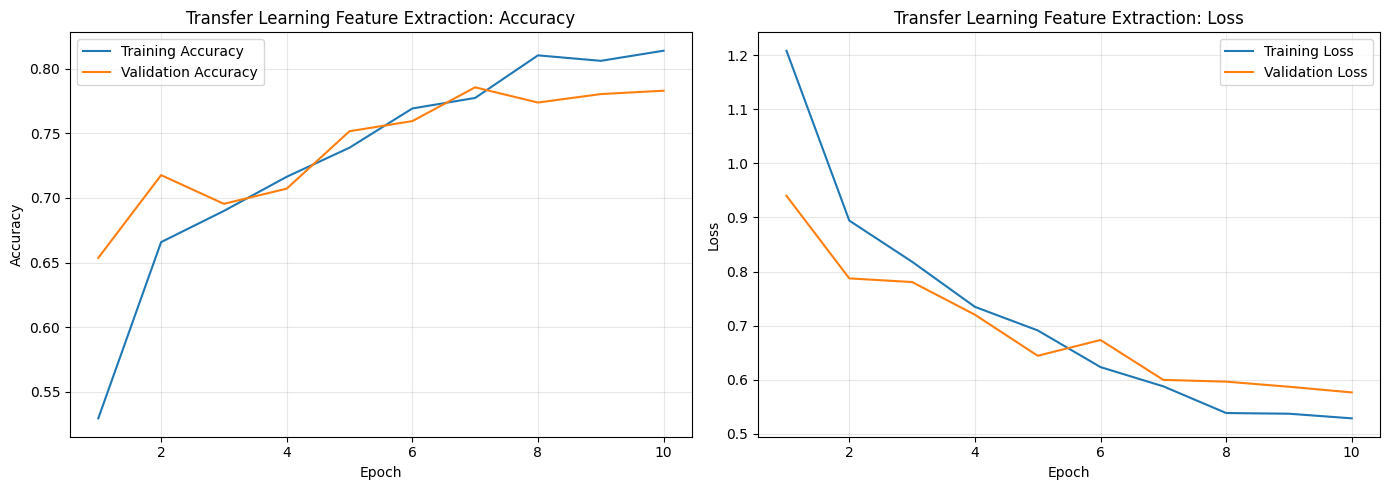

In [19]:
EPOCHS_TRANSFER_FEATURE_EXTRACTION = 10

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_feature_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_TRANSFER_FEATURE_EXTRACTION,
    callbacks=make_callbacks(patience=3)
)

plot_training_history(
    transfer_feature_history,
    'Transfer Learning Feature Extraction'
)


## Cell 16: Fine-Tuning

Unfrozen base layers: 19 / 154
Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8737 - loss: 0.3619 - val_accuracy: 0.8301 - val_loss: 0.4724 - learning_rate: 1.0000e-05
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8711 - loss: 0.3657 - val_accuracy: 0.8275 - val_loss: 0.4778 - learning_rate: 1.0000e-05
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8672 - loss: 0.3697 - val_accuracy: 0.8314 - val_loss: 0.4688 - learning_rate: 1.0000e-05
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8799 - loss: 0.3474 - val_accuracy: 0.8248 - val_loss: 0.4765 - learning_rate: 1.0000e-05
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8688 - loss: 0.3573 - val_accuracy: 0.8288 - val_loss: 0.4615 - learning_rate: 1.0000e-05
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8796 - loss: 0.3475 - val_accuracy: 0.8301 - val_loss: 0.4793 - learning_rate: 1.0000e-05
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 

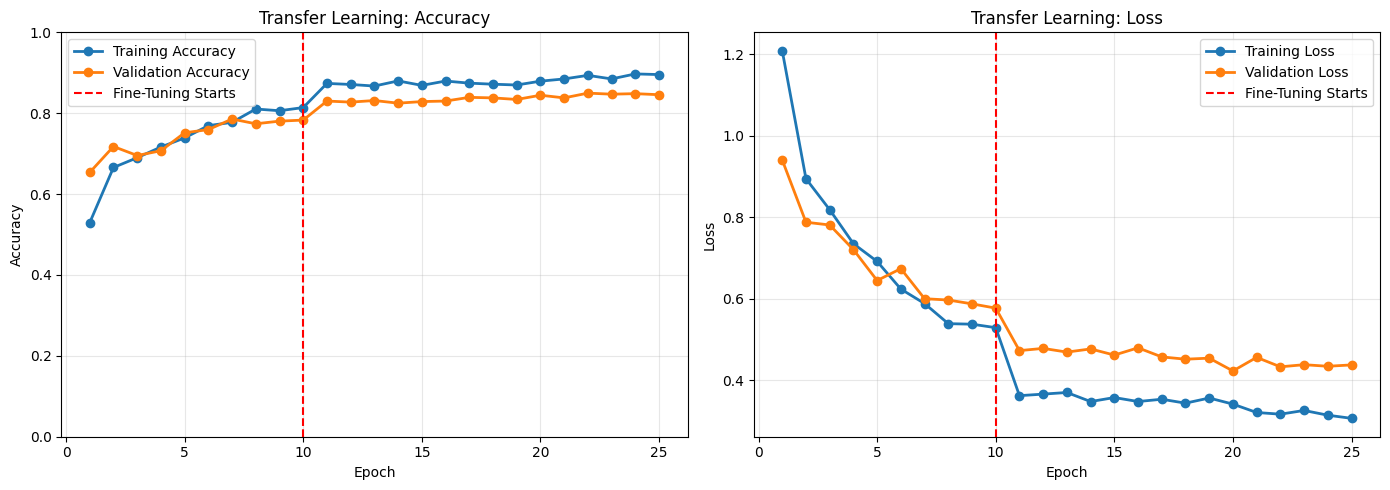

In [30]:
import matplotlib.pyplot as plt
import tensorflow as tf

# =========================
# FINE-TUNE MODEL
# =========================

transfer_base_model.trainable = True

fine_tune_at = max(0, len(transfer_base_model.layers) - 30)

for layer in transfer_base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in transfer_base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

unfrozen = sum(layer.trainable for layer in transfer_base_model.layers)
print(f'Unfrozen base layers: {unfrozen} / {len(transfer_base_model.layers)}')

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_fine_tune_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=make_callbacks(patience=5),
    verbose=1
)

# =========================
# COMBINE FEATURE EXTRACTION + FINE-TUNING HISTORY
# =========================

combined_history = {}

for metric in ['accuracy', 'val_accuracy', 'loss', 'val_loss']:
    combined_history[metric] = (
        transfer_feature_history.history[metric]
        + transfer_fine_tune_history.history[metric]
    )

total_epochs = len(combined_history['accuracy'])
fine_tune_start = len(transfer_feature_history.history['accuracy'])

epochs_range = range(1, total_epochs + 1)

# =========================
# CORRECT TRANSFER LEARNING GRAPH
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    epochs_range,
    combined_history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)
axes[0].plot(
    epochs_range,
    combined_history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)
axes[0].axvline(
    fine_tune_start,
    color='red',
    linestyle='--',
    label='Fine-Tuning Starts'
)
axes[0].set_title('Transfer Learning: Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    epochs_range,
    combined_history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)
axes[1].plot(
    epochs_range,
    combined_history['val_loss'],
    marker='o',
    linewidth=2,
    label='Validation Loss'
)
axes[1].axvline(
    fine_tune_start,
    color='red',
    linestyle='--',
    label='Fine-Tuning Starts'
)
axes[1].set_title('Transfer Learning: Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#  second wala
# import matplotlib.pyplot as plt

# history = transfer_fine_tune_history.history
# epochs_range = range(1, len(history['accuracy']) + 1)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Accuracy
# axes[0].plot(epochs_range, history['accuracy'], label='Training Accuracy')
# axes[0].plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')
# axes[0].set_title('Transfer Learning Fine-Tuning: Accuracy')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Accuracy')
# axes[0].set_ylim(0, 1)
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Loss
# axes[1].plot(epochs_range, history['loss'], label='Training Loss')
# axes[1].plot(epochs_range, history['val_loss'], label='Validation Loss')
# axes[1].set_title('Transfer Learning Fine-Tuning: Loss')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Loss')
# axes[1].set_ylim(0, 1)
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# first waala
# transfer_base_model.trainable = True

# # Unfreeze last 30 layers — 10 was too conservative for alpha=0.35
# fine_tune_at = max(0, len(transfer_base_model.layers) - 30)

# for layer in transfer_base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# # Freeze BatchNorm — keep this
# for layer in transfer_base_model.layers:
#     if isinstance(layer, layers.BatchNormalization):
#         layer.trainable = False

# unfrozen = sum(1 for l in transfer_base_model.layers if l.trainable)
# print(f'Unfrozen base layers: {unfrozen} / {len(transfer_base_model.layers)}')

# # LR = 1e-5: an order of magnitude smaller than the head was trained at (1e-3),
# # but still large enough to actually update weights. 1e-6 was dead.
# transfer_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# transfer_fine_tune_history = transfer_model.fit(
#     train_dataset,
#     validation_data=validation_dataset,
#     epochs=EPOCHS_TRANSFER_FINE_TUNING,
#     callbacks=make_callbacks(patience=5)
# )

# plot_training_history(transfer_fine_tune_history, 'Transfer Learning Fine-Tuning')
# transfer_results = evaluate_model(
#     transfer_model, validation_dataset, class_names, 'MobileNetV2 Transfer Learning'
# )

## Cell 17: Final Comparison

In [27]:
model_results['MobileNetV2 Transfer Learning'] = transfer_results
print_results_table(model_results)

Model                                 Accuracy  Precision     Recall   F1-score
--------------------------------------------------------------------------------
Improved Baseline CNN                   0.6105     0.6102     0.6105     0.6022
Deeper CNN                              0.7059     0.7563     0.7059     0.7018
MobileNetV2 Transfer Learning           0.8235     0.8280     0.8235     0.8230


## Cell 18: Prediction / Inference

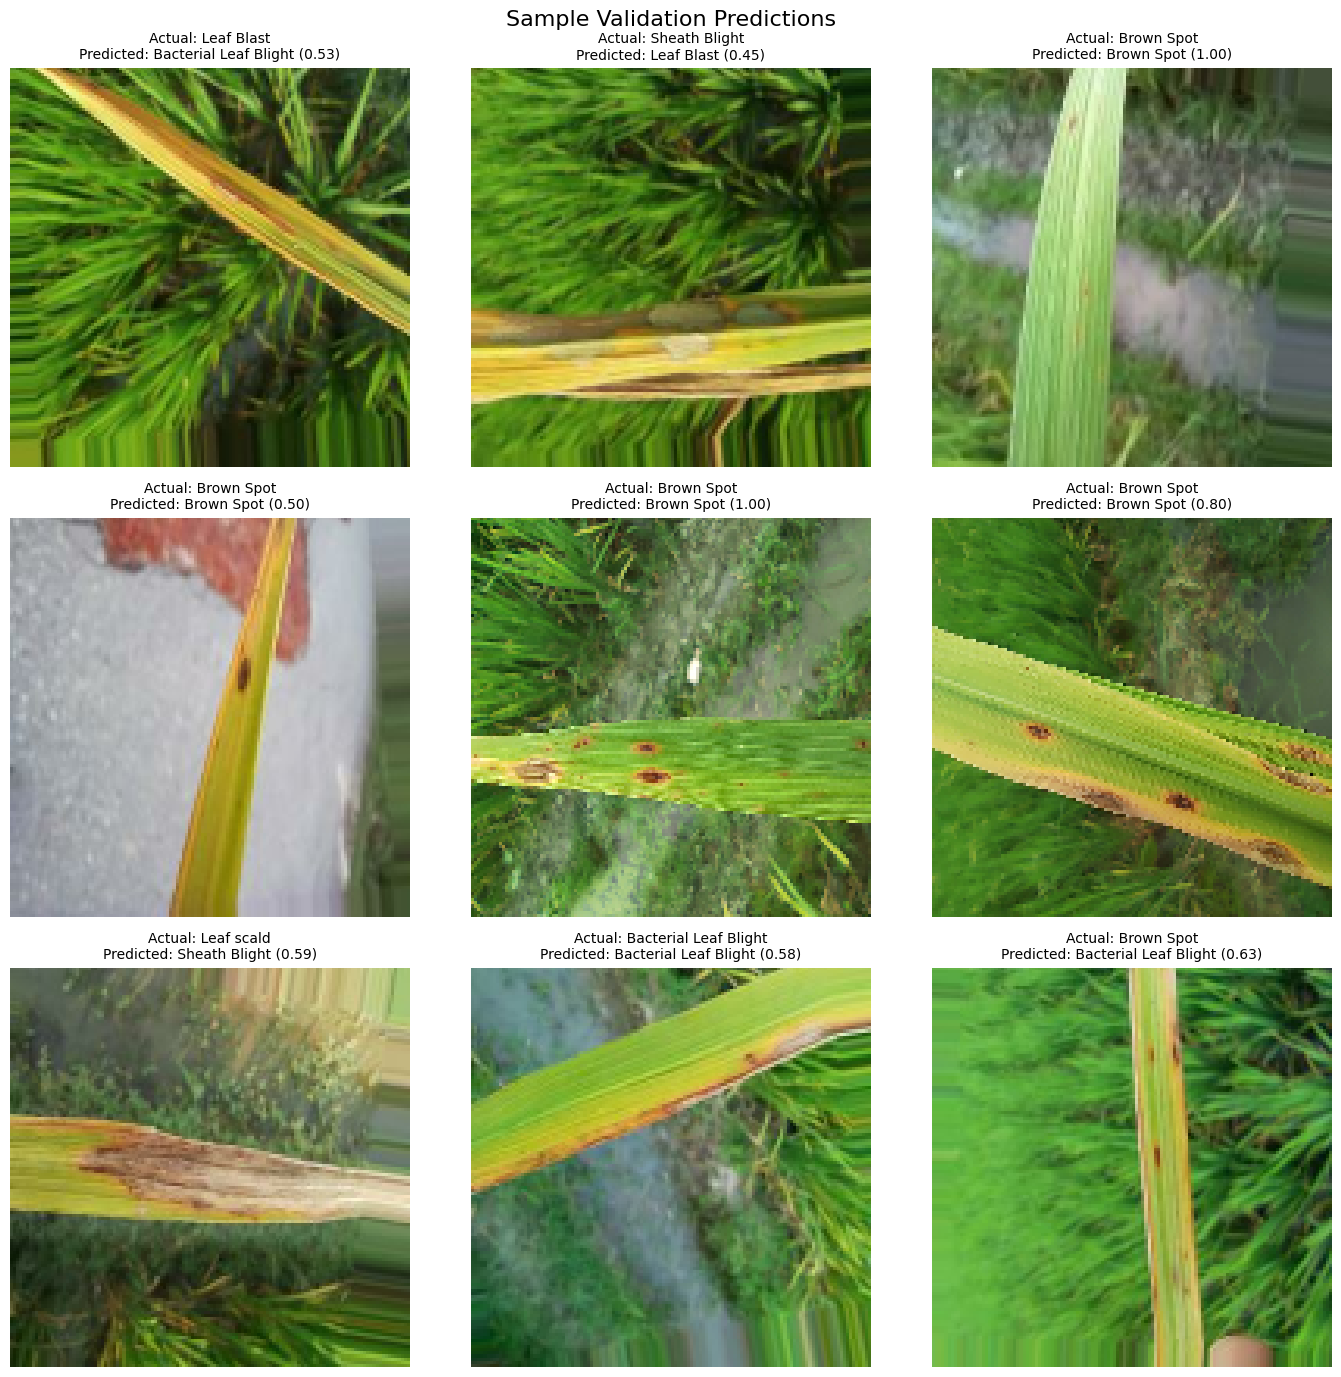

In [28]:
best_model = transfer_model

plt.figure(figsize=(14, 14))
for images, labels in validation_dataset.take(1):
    probabilities = best_model.predict(images, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)

    for i in range(min(9, images.shape[0])):
        actual_label = class_names[int(labels[i])]
        predicted_label = class_names[int(predicted_labels[i])]
        confidence = np.max(probabilities[i])

        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f'Actual: {actual_label}\nPredicted: {predicted_label} ({confidence:.2f})', fontsize=10)
        plt.axis('off')

plt.suptitle('Sample Validation Predictions', fontsize=16)
plt.tight_layout()
plt.show()

## Cell 19: Short Explanation

Baseline CNN uses three convolutional blocks, pooling, three Dense layers, Dropout, and Softmax. The model uses GlobalAveragePooling2D to reduce overfitting compared with a large Flatten layer.

The deeper CNN doubles the convolutional depth and adds Batch Normalization plus Dropout.

The optimizer comparison trains the same deeper architecture with SGD and Adam. Adam usually converges faster, while SGD may sometimes generalize well.

Transfer learning uses MobileNetV2 pretrained on ImageNet. The first stage freezes the base model, and the second stage fine-tunes only the last few layers with a low learning rate.